# Data Profiling — Prediksi Ketepatan Lulus Mahasiswa

Notebook ini mereplay eksplorasi database SQL Server `LITIGASI` yang dilakukan secara iteratif.
Setiap section mendokumentasikan satu tahap eksplorasi beserta output dan keputusan yang diambil.

Database: SQL Server 2022 (Docker container `sqlserver`)
Koneksi: `pymssql` via Python

In [13]:
import pymssql
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

conn = pymssql.connect(server='localhost', port=1433, user='sa', password='MSSQL01#', database='LITIGASI')

def query(sql):
    return pd.read_sql(sql, conn)

print("Koneksi berhasil ke database LITIGASI")

Koneksi berhasil ke database LITIGASI


## 1. Overview tblMHS — Data Master Mahasiswa

Tabel utama yang menyimpan identitas dan status mahasiswa.

In [14]:
# Total mahasiswa
total = query("SELECT COUNT(*) AS total FROM dbo.tblMHS")
print(f"Total mahasiswa: {total.iloc[0,0]}")

# Distribusi program
print("\nDistribusi program (Kode_jp):")
display(query("SELECT Kode_jp, COUNT(*) AS jml FROM dbo.tblMHS GROUP BY Kode_jp ORDER BY Kode_jp"))

# Mapping program dari TblJurusan
print("\nDetail program:")
display(query("SELECT Kode_Jp, Jurusan, Program FROM dbo.TblJurusan"))

Total mahasiswa: 1621

Distribusi program (Kode_jp):


,Kode_jp,jml
0,AP,386
1,IH,1235



Detail program:


,Kode_Jp,Jurusan,Program
0,AP,Administrasi Peradilan,D3
1,IH,Ilmu Hukum,S1


## 2. Distribusi Status & Angkatan

Memahami distribusi status mahasiswa dan sebaran angkatan untuk menentukan target variable.

Status mahasiswa (keseluruhan):


,Status,jml
0,NaN,2
1,-,1
2,A,11
3,Aktif,612
4,Cuti,41
5,D,1
6,Keluar,155
7,L,621
8,Lulus,177



Status per program:


,Status,Kode_jp,jml
0,Aktif,AP,55
1,Cuti,AP,4
2,Keluar,AP,25
3,L,AP,302
4,NaN,IH,2
5,-,IH,1
6,A,IH,11
7,Aktif,IH,557
8,Cuti,IH,37
9,D,IH,1



Distribusi angkatan:


,angkatan,jml
0,2014,168
1,2015,147
2,2016,79
3,2017,83
4,2018,63
5,2019,62
6,2020,43
7,2021,91
8,2022,267
9,2023,185


<Axes: title={'center': 'Mahasiswa per Angkatan'}, xlabel='angkatan'>

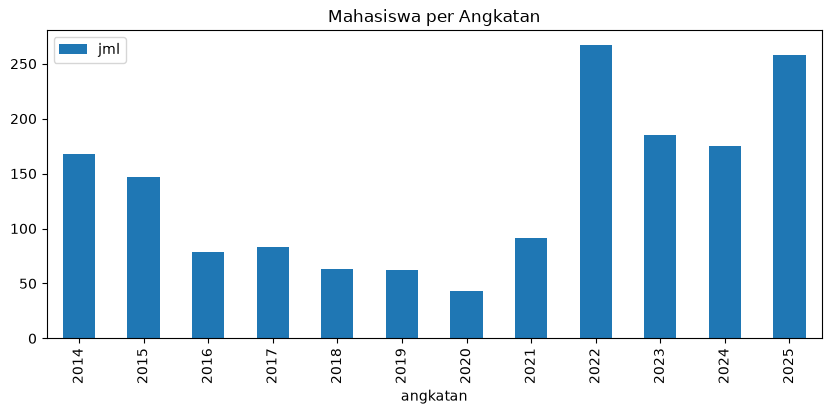

In [15]:
print("Status mahasiswa (keseluruhan):")
display(query("SELECT Status, COUNT(*) AS jml FROM dbo.tblMHS GROUP BY Status ORDER BY Status"))

print("\nStatus per program:")
display(query("""
SELECT Status, Kode_jp, COUNT(*) AS jml 
FROM dbo.tblMHS 
GROUP BY Status, Kode_jp 
ORDER BY Kode_jp, Status
"""))

print("\nDistribusi angkatan:")
angkatan = query("SELECT ThMasuk AS angkatan, COUNT(*) AS jml FROM dbo.tblMHS GROUP BY ThMasuk ORDER BY ThMasuk")
display(angkatan)
angkatan.plot.bar(x='angkatan', y='jml', title='Mahasiswa per Angkatan', figsize=(10,4))

**Keputusan dari profiling ini:**
- Target: Status 'L' dan 'Lulus' = lulus. Status 'Keluar' = dropout.
- Status 'Aktif'/'Cuti' tidak bisa dipakai karena outcome belum diketahui.
- Angkatan 2024-2025 masih terlalu baru → minim data semester.

## 3. Profiling IPSIPK — Performa Akademik Per Semester

Tabel kunci untuk fitur `ips_sem1-4`, `ipk_sem4`, `sks_sem1-4`.

In [5]:
# Total records dan cakupan mahasiswa
print("Cakupan IPSIPK untuk AP/IH:")
display(query("""
SELECT COUNT(*) AS total_records, COUNT(DISTINCT i.Nim) AS students
FROM dbo.IPSIPK i
INNER JOIN dbo.tblMHS m ON i.Nim = m.Nim
WHERE m.Kode_jp IN ('AP','IH')
"""))

# Sample data
print("\nSample IPSIPK (5 baris):")
display(query("""
SELECT TOP 5 i.Nim, i.Thn_Akademik, i.Periode, i.TSKS, i.ips, i.TTSKS, i.IPK, m.ThMasuk, m.Status
FROM dbo.IPSIPK i
INNER JOIN dbo.tblMHS m ON i.Nim = m.Nim
WHERE m.Kode_jp IN ('AP','IH')
ORDER BY i.Nim, i.Thn_Akademik, i.Periode
"""))

# Periode values (deteksi 'K')
print("\nNilai unik Periode:")
display(query("SELECT DISTINCT Periode FROM dbo.IPSIPK"))

Cakupan IPSIPK untuk AP/IH:


,total_records,students
0,6228,1605



Sample IPSIPK (5 baris):


,Nim,Thn_Akademik,Periode,TSKS,ips,TTSKS,IPK,ThMasuk,Status
0,207421001,2020-2021,1,20,2.90,20,2.90,2020,L
1,207421001,2020-2021,2,21,3.43,41,3.17,2020,L
2,207421001,2021-2022,1,18,3.17,59,3.17,2020,L
3,207421001,2021-2022,2,19,3.63,78,3.28,2020,L
4,207421001,2022-2023,1,21,3.43,99,3.31,2020,L



Nilai unik Periode:


,Periode
0,2
1,1
2,K


**Temuan:** Ada periode `K` (semester pendek/summer) selain `1` (Ganjil) dan `2` (Genap).

**Keputusan:** Periode `K` di-map ke nilai 3 untuk pengurutan, sehingga urutannya: 1 < 2 < K.

## 4. Data Quality: NULL Rate di IPSIPK

Berapa banyak record yang memiliki IPS NULL? Apakah terkonsentrasi di angkatan tertentu?

NULL rate IPSIPK per angkatan:


,ThMasuk,total_records,null_ips,null_pct
0,2014,553,551,99.6
1,2015,668,311,46.6
2,2016,403,170,42.2
3,2017,392,152,38.8
4,2018,258,75,29.1
5,2019,249,58,23.3
6,2020,172,0,0.0
7,2021,350,0,0.0
8,2022,1576,0,0.0
9,2023,819,0,0.0


<Axes: title={'center': '% IPS NULL per Angkatan'}, xlabel='ThMasuk'>

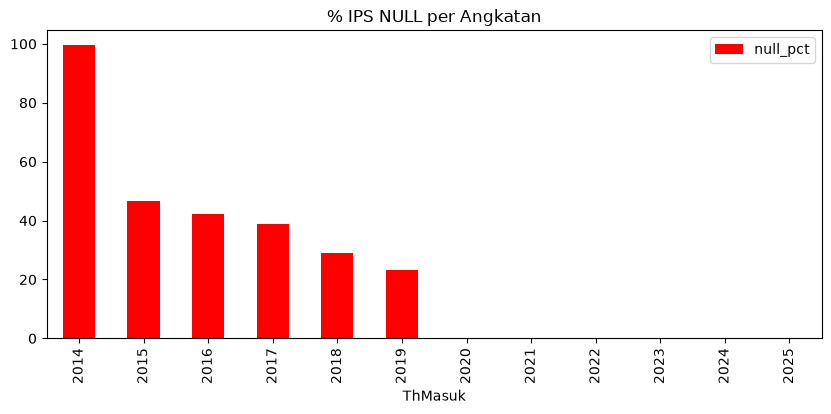

In [6]:
# NULL rate per angkatan
print("NULL rate IPSIPK per angkatan:")
null_rate = query("""
SELECT m.ThMasuk,
       COUNT(*) AS total_records,
       SUM(CASE WHEN i.ips IS NULL THEN 1 ELSE 0 END) AS null_ips,
       ROUND(CAST(SUM(CASE WHEN i.ips IS NULL THEN 1 ELSE 0 END) AS FLOAT) / COUNT(*) * 100, 1) AS null_pct
FROM dbo.IPSIPK i
INNER JOIN dbo.tblMHS m ON i.Nim = m.Nim
WHERE m.Kode_jp IN ('AP','IH')
GROUP BY m.ThMasuk
ORDER BY m.ThMasuk
""")
display(null_rate)

# Visualisasi
null_rate.plot.bar(x='ThMasuk', y='null_pct', title='% IPS NULL per Angkatan', figsize=(10,4), color='red')

**Temuan kritis:** Angkatan 2014-2015 punya NULL rate 70-100%. Ini efek migrasi vendor — sistem lama tidak mencatat IPS per semester.

**Keputusan:** Angkatan dengan NULL rate tinggi tidak bisa dipakai. Threshold minimum: 1 semester dengan IPS valid dalam 4 semester pertama.

## 5. Mencari Tabel Nilai ("tblNilai")

Proposal menyebut sumber data "tblNilai" tapi tabel ini tidak ada di database.
Kita perlu mencari tabel pengganti.

In [7]:
# Cari semua tabel dengan "Nilai" di namanya
print("Tabel dengan 'Nilai' di nama:")
tables = query("""
SELECT TABLE_NAME FROM INFORMATION_SCHEMA.TABLES 
WHERE TABLE_NAME LIKE '%Nilai%' OR TABLE_NAME LIKE '%nilai%'
ORDER BY TABLE_NAME
""")
display(tables)

# Cek kandidat terkuat: HtblNilai
print("\nHtblNilai — total rows & unique students:")
display(query("SELECT COUNT(*) AS total_rows, COUNT(DISTINCT Nim) AS unique_students FROM dbo.HtblNilai"))

# Sample NIM
print("Sample NIM dari HtblNilai:")
display(query("SELECT DISTINCT TOP 5 Nim FROM dbo.HtblNilai"))

Tabel dengan 'Nilai' di nama:


,TABLE_NAME
0,ABK_Nilai
1,att_tblnilai
2,deltblNilai
3,feed_nilai
4,FilterNilaiMK
5,HtblNilai
6,MHS_Nilai
7,Qnilai_mhs
8,QNilaiAP
9,QNilaiSumAP



HtblNilai — total rows & unique students:


,total_rows,unique_students
0,39990,1416


Sample NIM dari HtblNilai:


,Nim
0,0301020026
1,0301021001
2,0301021002
3,0301021004
4,0301021007


In [8]:
# KRITIS: Cek overlap NIM antara HtblNilai dan tblMHS
print("Overlap NIM HtblNilai ↔ tblMHS:")
overlap = query("""
SELECT COUNT(DISTINCT h.Nim) AS overlap_count
FROM dbo.HtblNilai h
INNER JOIN dbo.tblMHS m ON h.Nim = m.Nim
""")
print(f"Overlap: {overlap.iloc[0,0]} — TIDAK ADA!")

# Coba Qnilai_mhs
print("\nQnilai_mhs — overlap dengan tblMHS:")
display(query("""
SELECT COUNT(*) AS total_rows, 
       COUNT(DISTINCT n.Nim) AS unique_students,
       COUNT(DISTINCT CASE WHEN m.Nim IS NOT NULL THEN n.Nim END) AS matched_students
FROM dbo.Qnilai_mhs n
LEFT JOIN dbo.tblMHS m ON n.Nim = m.Nim AND m.Kode_jp IN ('AP','IH')
"""))

Overlap NIM HtblNilai ↔ tblMHS:
Overlap: 0 — TIDAK ADA!

Qnilai_mhs — overlap dengan tblMHS:


,total_rows,unique_students,matched_students
0,54587,1605,1605


**Temuan kritis:** `HtblNilai` — 0% overlap NIM dengan `tblMHS`. Format NIM berbeda (sistem legacy vs sistem baru).

**Keputusan:** Gunakan `Qnilai_mhs` sebagai tabel nilai. Overlap: 1605 dari 1621 mahasiswa.

**Mengapa ini penting:** Ini adalah jebakan umum dalam proyek data mining — nama tabel tidak selalu mencerminkan isinya. Tanpa profiling, kita bisa saja memakai `HtblNilai` dan menghasilkan dataset kosong.

## 6. Profiling Qnilai_mhs — Distribusi Nilai & Kehadiran

In [9]:
# Distribusi nilai huruf
print("Distribusi nilai:")
display(query("""
SELECT Nilai, COUNT(*) AS jml 
FROM dbo.Qnilai_mhs 
GROUP BY Nilai 
ORDER BY 
    CASE Nilai WHEN 'A' THEN 1 WHEN 'A-' THEN 2 WHEN 'B+' THEN 3 
         WHEN 'B' THEN 4 WHEN 'B-' THEN 5 WHEN 'C+' THEN 6 
         WHEN 'C' THEN 7 WHEN 'D' THEN 8 WHEN 'E' THEN 9 
         WHEN 'T' THEN 10 ELSE 99 END
"""))

# Profiling kehadiran
print("\nProfil kehadiran:")
display(query("""
SELECT 
    COUNT(*) AS total,
    COUNT(CASE WHEN Kehadiran IS NULL THEN 1 END) AS null_count,
    COUNT(CASE WHEN Kehadiran = 0 THEN 1 END) AS zero_count,
    COUNT(CASE WHEN Kehadiran > 0 THEN 1 END) AS positive_count,
    ROUND(CAST(COUNT(CASE WHEN Kehadiran > 0 THEN 1 END) AS FLOAT) / COUNT(*) * 100, 1) AS positive_pct
FROM dbo.Qnilai_mhs n
INNER JOIN dbo.tblMHS m ON n.Nim = m.Nim
WHERE m.Kode_jp IN ('AP','IH')
"""))

Distribusi nilai:


,Nilai,jml
0,A,17787
1,B,28010
2,C,787
3,D,49
4,E,1130
5,T,188
6,-,6575
7,,61



Profil kehadiran:


,total,null_count,zero_count,positive_count,positive_pct
0,54587,13849,30786,9952,18.2


**Temuan:** Kehadiran hanya terisi 18.2% dari record. 56.4% bernilai 0 (kemungkinan sistem tidak mencatat, bukan berarti tidak hadir).

**Keputusan:** Fitur `avg_attendance` akan sangat sparse (~53% missing di dataset final). Model Decision Tree bisa handle missing values. Supplement dengan `Kul_Kehadiran` (146 mahasiswa tambahan).

## 7. Deteksi Fitur Zero-Variance

Fitur yang nilainya hampir semua sama tidak informatif untuk model. Perlu dideteksi dan dihapus.

In [10]:
# Deteksi fitur demografi dengan near-zero variance
print("Deteksi zero-variance di tblMHS (AP/IH):\n")

checks = {
    'JalurMasuk': "SELECT COUNT(DISTINCT JalurMasuk) FROM dbo.tblMHS WHERE Kode_jp IN ('AP','IH')",
    'Gelombang': "SELECT COUNT(DISTINCT Gelombang) FROM dbo.tblMHS WHERE Kode_jp IN ('AP','IH')",
    'penerima_kps': "SELECT COUNT(DISTINCT penerima_kps) FROM dbo.tblMHS WHERE Kode_jp IN ('AP','IH')",
    'id_jenis_daftar': "SELECT COUNT(DISTINCT id_jenis_daftar) FROM dbo.tblMHS WHERE Kode_jp IN ('AP','IH')",
    'id_jalur_masuk': "SELECT COUNT(DISTINCT id_jalur_masuk) FROM dbo.tblMHS WHERE Kode_jp IN ('AP','IH')",
    'Status_Masuk': "SELECT COUNT(DISTINCT Status_Masuk) FROM dbo.tblMHS WHERE Kode_jp IN ('AP','IH')",
    'Jenis_Kel': "SELECT COUNT(DISTINCT Jenis_Kel) FROM dbo.tblMHS WHERE Kode_jp IN ('AP','IH')",
    'id_agama': "SELECT COUNT(DISTINCT id_agama) FROM dbo.tblMHS WHERE Kode_jp IN ('AP','IH')",
}

for col, sql in checks.items():
    n_unique = query(sql).iloc[0,0]
    status = "✓ KEEP" if n_unique > 3 else "✗ DROP (zero-variance)"
    print(f"  {col:20s}: {n_unique} unique values → {status}")

Deteksi zero-variance di tblMHS (AP/IH):

  JalurMasuk          : 0 unique values → ✗ DROP (zero-variance)
  Gelombang           : 0 unique values → ✗ DROP (zero-variance)
  penerima_kps        : 1 unique values → ✗ DROP (zero-variance)
  id_jenis_daftar     : 1 unique values → ✗ DROP (zero-variance)
  id_jalur_masuk      : 3 unique values → ✗ DROP (zero-variance)
  Status_Masuk        : 2 unique values → ✗ DROP (zero-variance)
  Jenis_Kel           : 2 unique values → ✗ DROP (zero-variance)
  id_agama            : 5 unique values → ✓ KEEP


## 8. Ringkasan Temuan & Keputusan

| # | Temuan | Keputusan |
|---|--------|-----------|
| 1 | Database `LITIGASI` punya 405 tabel, hanya 4 yang relevan | Gunakan `tblMHS`, `IPSIPK`, `Qnilai_mhs`, `Kul_Kehadiran` |
| 2 | `HtblNilai` 0% overlap NIM — format berbeda | Tolak, gunakan `Qnilai_mhs` |
| 3 | `Perwalian.TSKSB` seluruhnya NULL | Tolak, gunakan `IPSIPK.TSKS` |
| 4 | Periode `K` (semester pendek) ditemukan | Map ke nilai 3 untuk pengurutan |
| 5 | Angkatan 2014-2015: IPSIPK 70-100% NULL | Exclude dari dataset (efek migrasi vendor) |
| 6 | Kehadiran hanya 18% terisi di Qnilai_mhs | `avg_attendance` akan sparse — supplement dengan Kul_Kehadiran |
| 7 | 5 fitur demografi zero-variance | Drop: JalurMasuk, Gelombang, penerima_kps, id_jenis_daftar, id_jalur_masuk |
| 8 | 401 mahasiswa Aktif/Cuti — outcome unknown | Exclude dari dataset |

In [11]:
conn.close()
print("Koneksi database ditutup.")
print("\nLanjut ke: extract_dataset.py untuk Data Preparation")

Koneksi database ditutup.

Lanjut ke: extract_dataset.py untuk Data Preparation
